In [ ]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [ ]:
from stericheight.data_handler import *
from stericheight.plotting_fns import PlottingFns
from stericheight.utils import Utils
from load_meop import MEOP
from region import Region
from composite import Composite
pfns = PlottingFns()

In [ ]:
import gsw
import glob
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.optimize import root_scalar


fname_spira = '../data/qc_profile_ds_2dbar.nc'

In [ ]:
sla = SLA(deg=0.25).da
sice = xr.open_dataset('../data/NSIDC/sice_processed.nc')
sice = sice.__xarray_dataarray_variable__
elevation_ = GEBCO(coarsen_factor=1).ds.elevation

In [ ]:
def sanom(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()

In [ ]:
extent =[139, 150,-68,-64]
elevation = elevation_.sel(latitude = slice(extent[2], extent[3]), longitude = slice(extent[0],extent[1]))
mertz = Region('Mertz',extent)


In [ ]:
# set up lines of constant density

def sig0range(tlims,slims):
    sig0_n = 100
    temprange = np.linspace(tlims[0],tlims[1],sig0_n)
    psalrange = np.linspace(slims[0],slims[1],sig0_n)

    sig0range = np.zeros((sig0_n,sig0_n))
    for i,t in enumerate(temprange):
        for j,s in enumerate(psalrange):
            sig0range[i,j]=gsw.sigma0(gsw.conversions.SA_from_SP(s,0,145,-67),gsw.CT_from_t(s,t,0))
    return temprange,psalrange,sig0range


In [ ]:
ds = xr.open_dataset(fname_spira).swap_dims({'n_prof':'time'})
ds = ds.where(
    (ds.lon > extent[0]) &
    (ds.lon < extent[1]) &
    (ds.lat > extent[2]) &
    (ds.lat < extent[3]), drop=True
)

In [ ]:
samp=ds.isel(time=10,pres=20)
print('pre-calc rho = {}'.format(samp.rho.item()))
print('gsw rho = {}'.format(gsw.density.rho(samp.asal,samp.ctemp,samp.pres-10.1325).item()))
print('gsw sigma0 = {}'.format(gsw.density.sigma0(samp.psal,samp.temp).item()))
print('gsw sigma1 = {}'.format(gsw.density.sigma1(samp.psal,samp.temp).item()))


pre-calc rho = 1027.2393798828125
gsw rho = 1027.3829312859093
gsw sigma0 = 27.107917827936262
gsw sigma1 = 31.871682778746845


In [ ]:
t1 = pd.Timestamp(2017,9,1)
t2 = pd.Timestamp(2017,12,31)
dec17 = meop.ds.sortby('time').sel(time=slice(t1,t2))
iced17 = sanom(sice).sel(time=slice(t1,t2)).mean('time')#.sel(time=pd.Timestamp(2017,12,1),method='nearest')
markers=['x','.','d','s']

pcs=set(dec17.profile_code.to_numpy())

fig,ax1 = plt.subplots(figsize=(6,4),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax=ax1,da=iced17,extent=[137.5,142.5,-67,-65.8],cbar_orientation='vertical',cbar='SICA',cmap=cmocean.cm.ice,vmin=-0.4,vmax=0.4)

fig,ax2= plt.subplots(figsize=(10,2))
for m,pc in zip(markers,pcs):
    datapc = dec17.where(dec17.profile_code==pc,drop=True).sel(pres=10)
    ax2.plot(datapc.time,datapc.psal,label=pc,marker=m)#,c=datapc.time)

    ax1.scatter(datapc.lon,datapc.lat,transform=ccrs.PlateCarree(),marker=m,vmin=t1.to_datetime64(),vmax=t2.to_datetime64())
ax2.legend()



AttributeError: 'MEOP' object has no attribute 'ds'

In [ ]:
ds['elevation'] = elevation.interp(latitude=ds.lat,longitude=ds.lon).drop(['longitude','latitude'])
ds['month'] = ds.time.dt.month
sice['month'] = sice.time.dt.month
sla['month'] = sla.time.dt.month
ds['year'] = ds.time.dt.year
ds


/tmp/ipykernel_33234/4069195758.py:1: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds_all['elevation'] = elevation.interp(latitude=ds_all.lat,longitude=ds_all.lon).drop(['longitude','latitude'])


<xarray.Dataset> Size: 165MB
Dimensions:       (time: 11706, pres: 501)
Coordinates:
  * time          (time) datetime64[ns] 94kB 2004-10-28T21:36:00.003089408 .....
  * pres          (pres) int64 4kB 0 2 4 6 8 10 12 ... 990 992 994 996 998 1000
    lon           (time) float64 94kB 145.2 142.5 143.5 142.9 ... nan nan nan
    lat           (time) float64 94kB -67.06 -64.01 -64.21 ... nan nan nan
    n_prof        (time) float64 94kB 5.668e+05 1.199e+05 1.206e+05 ... nan nan
Data variables:
    temp          (time, pres) float64 47MB nan nan nan nan ... nan nan nan nan
    psal          (time, pres) float64 47MB nan nan nan nan ... nan nan nan nan
    dsource       (time) object 94kB 'CTD' 'Argo' 'Argo' 'Argo' ... nan nan nan
    mld           (time) float64 94kB 381.8 83.76 63.96 78.81 ... nan nan nan
    asal          (time, pres) float32 23MB nan nan nan nan ... nan nan nan nan
    ctemp         (time, pres) float32 23MB nan nan nan nan ... nan nan nan nan
    rho           (time, pres) float32 23MB nan nan nan nan ... nan nan nan nan
    mlp           (time) float64 94kB 386.0 82.0 60.0 78.0 ... nan nan nan nan
    profile_code  (time) object 94kB nan nan ... 'wd30-639-Vert-22'
    elevation     (time) float64 94kB -1.332e+03 -3.79e+03 ... nan nan
    month         (time) int64 94kB 10 4 5 5 5 2 2 2 2 2 ... 2 2 2 2 2 2 2 2 2 2
    year          (time) int64 94kB 2004 2006 2006 2006 ... 2024 2024 2024 2024
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [23]:
ds_shelf = ds_all.where(ds_all.elevation > -1000,drop=True)

In [25]:
ds_shelf

<xarray.Dataset> Size: 13MB
Dimensions:       (time: 928, pres: 501)
Coordinates:
  * time          (time) datetime64[ns] 7kB 2007-02-20T23:29:59.000002 ... 20...
  * pres          (pres) int64 4kB 0 2 4 6 8 10 12 ... 990 992 994 996 998 1000
    lon           (time) float64 7kB 140.0 140.0 140.0 ... 142.3 142.0 149.8
    lat           (time) float64 7kB -66.56 -66.58 -66.66 ... -65.66 -65.92
    n_prof        (time) float64 7kB 7.932e+05 7.932e+05 ... 8.109e+05 8.038e+05
Data variables:
    temp          (time, pres) float64 4MB nan nan nan ... 0.1953 0.1945 0.1937
    psal          (time, pres) float64 4MB nan nan nan ... 34.67 34.67 34.67
    dsource       (time) object 7kB 'MEOP' 'MEOP' 'MEOP' ... 'SOCCOM' 'SOCCOM'
    mld           (time) float64 7kB 65.34 17.82 49.5 49.5 ... 30.1 29.35 27.62
    asal          (time, pres) float32 2MB nan nan nan ... 34.84 34.84 34.84
    ctemp         (time, pres) float32 2MB nan nan nan ... 0.1965 0.1957 0.1949
    rho           (time, pres) float32 2MB nan nan nan ... 1.028e+03 1.028e+03
    mlp           (time) float64 7kB 52.0 14.0 42.0 50.0 ... 30.0 30.0 28.0
    profile_code  (time) object 7kB nan nan nan nan nan ... nan nan nan nan nan
    elevation     (time) float64 7kB -296.9 -96.14 -499.0 ... -876.3 -959.3
    month         (time) float64 7kB 2.0 2.0 2.0 2.0 2.0 ... 10.0 2.0 2.0 1.0
    year          (time) float64 7kB 2.007e+03 2.007e+03 ... 2.019e+03 2.02e+03
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [24]:
def get_seasons(dspira_mertz):
    seasons={}
    seasons['autumn']=dspira_mertz.where(((dspira_mertz.month >= 4) & (dspira_mertz.month <= 6)),drop=True)
    seasons['winter']=dspira_mertz.where(((dspira_mertz.month >= 7) & (dspira_mertz.month <= 9)),drop=True)
    seasons['spring']=dspira_mertz.where(((dspira_mertz.month >= 10) & (dspira_mertz.month <= 12)),drop=True)
    seasons['summer']=dspira_mertz.where(((dspira_mertz.month >= 1) & (dspira_mertz.month <= 3)),drop=True)
    return seasons
def assign_season(dspira_mertz):
    dspira_mertz['season']=dspira_mertz.where(((dspira_mertz.month >= 4) & (dspira_mertz.month <= 6)),drop=True)
    seasons['winter']=dspira_mertz.where(((dspira_mertz.month >= 7) & (dspira_mertz.month <= 9)),drop=True)
    seasons['spring']=dspira_mertz.where(((dspira_mertz.month >= 10) & (dspira_mertz.month <= 12)),drop=True)
    seasons['summer']=dspira_mertz.where(((dspira_mertz.month >= 1) & (dspira_mertz.month <= 3)),drop=True)
    return seasons
def alt_seasons(dspira_mertz):
    seasons={}
    seasons['autumn']=dspira_mertz.where(((dspira_mertz.month >= 3) & (dspira_mertz.month <= 5)),drop=True)
    seasons['winter']=dspira_mertz.where(((dspira_mertz.month >= 6) & (dspira_mertz.month <= 8)),drop=True)
    seasons['spring']=dspira_mertz.where(((dspira_mertz.month >= 9) & (dspira_mertz.month <= 11)),drop=True)
    seasons['summer']=dspira_mertz.where(((dspira_mertz.month == 12) | (dspira_mertz.month <= 2)),drop=True)
    return seasons
seasons = get_seasons(ds_shelf)
alt_seasons = alt_seasons(ds_shelf)

print(len(seasons['autumn'].time))
print(len(seasons['winter'].time))
print(len(seasons['spring'].time))
print(len(seasons['summer'].time))



268
92
150
418


In [ ]:
rows = ['Summer','Autumn','Winter','Spring']
cols = np.arange(2006,2021,1)
ally = xr.DataArray(cols, coords={'year':cols})

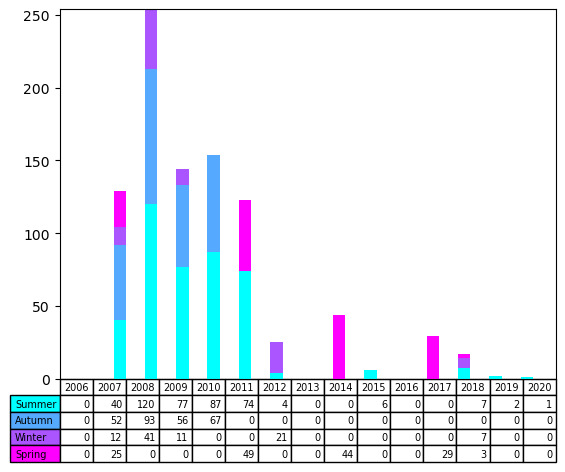

In [ ]:
prep4table = lambda season: seasons[season].groupby('time.year').count().dsource.reindex_like(ally,fill_value=0).values
data = [prep4table('summer'),
        prep4table('autumn'),
        prep4table('winter'),
        prep4table('spring')]

# values = np.arange(0, 2500, 500)
# value_increment = 1000
# Get some pastel shades for the colors
colors = plt.cm.cool(np.linspace(0, 1, len(rows)))
n_rows = len(data)
index = np.arange(len(cols)) + 0.3
bar_width = 0.4
# Initialize the vertical-offset for the stacked bar chart.
y_offset = np.zeros(len(cols))
# Plot bars and create text labels for the table
for row in range(n_rows):
    barc = plt.bar(index, data[row], bar_width, bottom=y_offset, color=colors[row])
    y_offset = y_offset + data[row]

plt.xticks([])
# Add a table at the bottom of the axes
the_table = plt.table(cellText=data,
                      rowLabels=rows,
                      rowColours=colors,
                      colLabels=cols,
                      loc='bottom')





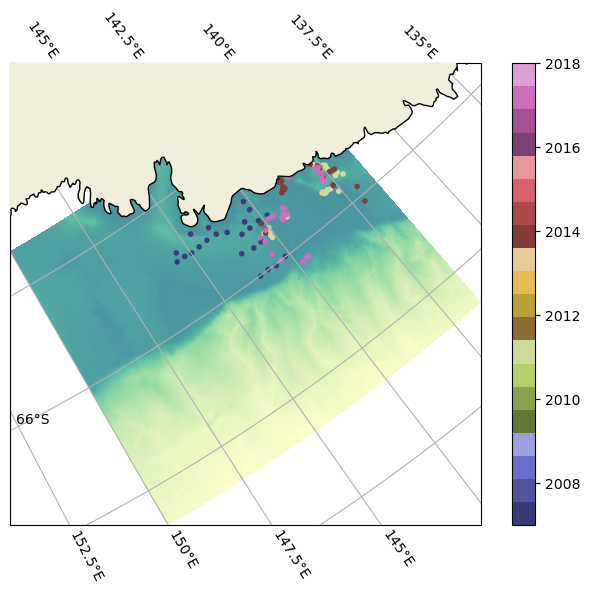

In [ ]:
l=-66.5
ss = 'spring'
excyears = [2018]#[2007,2009,2012,2019,2020]
dss = seasons[ss]#.where(seasons[ss].lat < l,drop=True).where(seasons[ss].lon < 144,drop=True)
#dsw = seasons[ss].where(seasons[ss].lon < l,drop=True)

fig,ax=plt.subplots(figsize=(8,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax,elevation,extent=extent,cmap=cmocean.cm.deep,land_zorder=3)

im=ax.scatter(dss.lon,dss.lat,c=dss.year,transform=ccrs.PlateCarree(),marker='.',cmap='tab20b')
#im=ax.scatter(dsw.lon,dsw.lat,transform=ccrs.PlateCarree(),marker='.')

plt.colorbar(im)

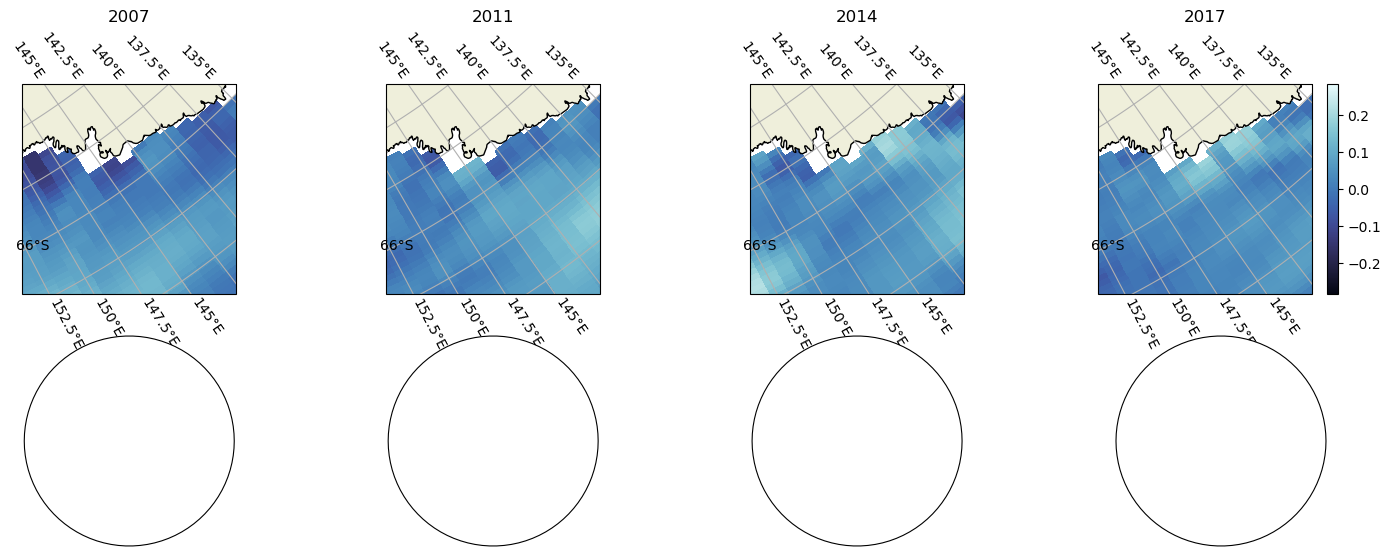

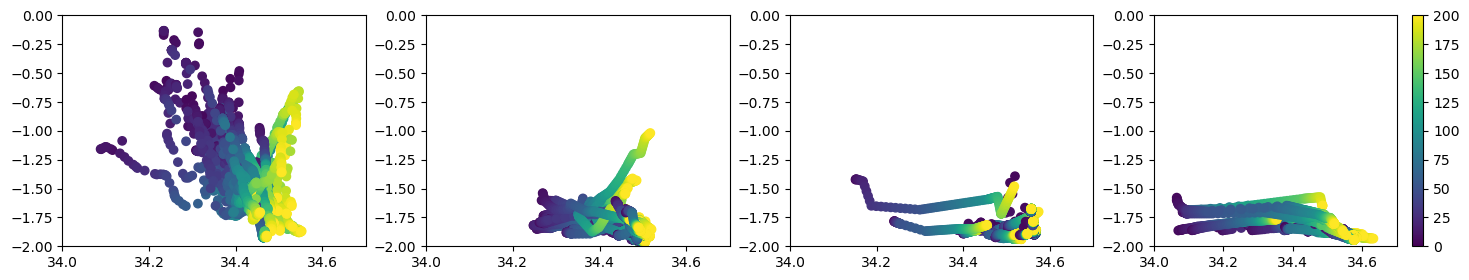

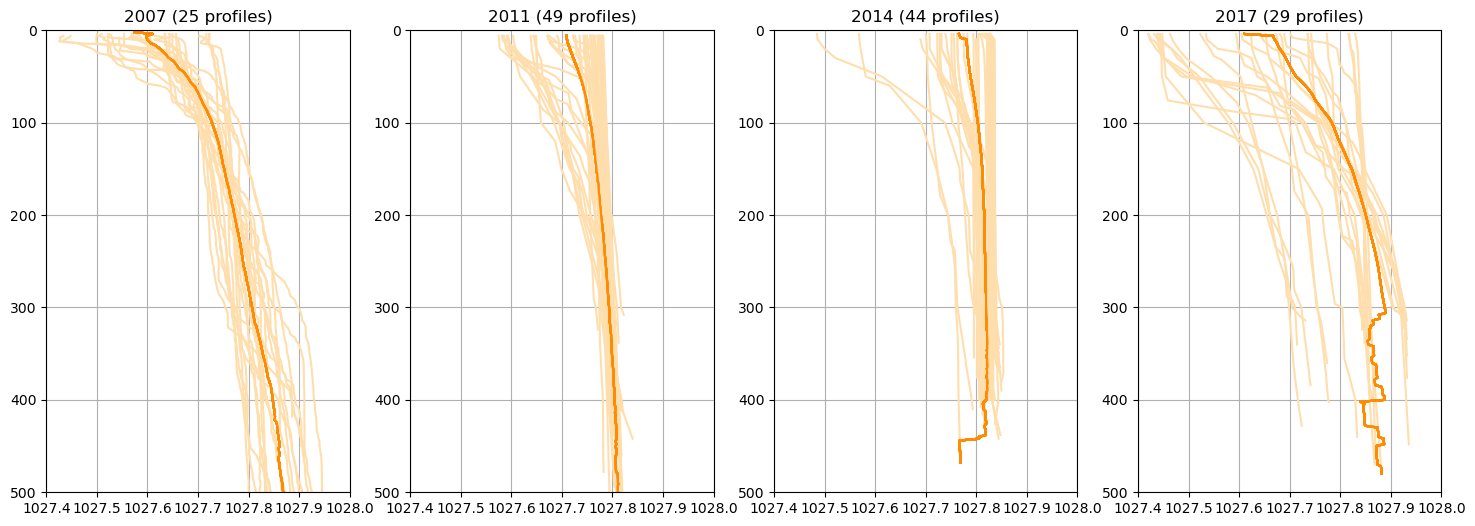

In [22]:
dse=dss
dse_yr = dse.groupby('time.year').mean()
dse_yr_cnt = dse.groupby('time.year').count()

# remove bad years
dse_yr = dse_yr.where(~dse_yr.year.isin(excyears),drop=True)
dse = dse.where(~dse.year.isin(excyears),drop=True)

n = len(dse_yr.year)

fig1,ax1 = plt.subplots(2,n,figsize=(18,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
fig2,ax2 = plt.subplots(1,n,figsize=(18,3))
fig3,ax3 = plt.subplots(1,n,figsize=(18,6))


for i,yr in enumerate(dse_yr.year):
    map_data=sanom(sice).where(sice.time.dt.year == yr,drop=True)
    data=dse.where(dse.year == yr,drop=True)

    im=pfns.sp(ax1[0][i],map_data.mean('time'),extent=extent,cmap=cmocean.cm.ice,land_zorder=1)
    #ax1[0][i].scatter(data.lon,data.lat,marker='x',c='r',transform=ccrs.PlateCarree())
    ax1[0][i].set_title(str(yr.item()))

    data2 = data.sel(pres=slice(4,200))
    for p in data2.time:
        data2t=data2.sel(time=p)
        im2=ax2[i].scatter(data2t.psal,data2t.temp,c=data2t.pres,vmin=0,vmax=200)

        datat=data.sel(time=p)
        ax3[i].plot(datat.rho,datat.pres,c='navajowhite')

        ax3[i].plot(dse_yr.sel(year=yr).rho,dse_yr.pres,c='darkorange')


    ax3[i].set_title(str(yr.item()) + ' ({} profiles)'.format(dse_yr_cnt.sel(year=yr).dsource.item()))
    ax3[i].grid()
    ax3[i].set_xlim([1027.4,1028])
    ax3[i].set_ylim([0,500])
    ax3[i].invert_yaxis()


    ax2[i].set_xlim([34,34.7])
    ax2[i].set_ylim([-2,0])
    # 2ax[i].invert_yaxis()
plt.colorbar(im)
plt.colorbar(im2)



In [31]:
data.sel(pres=10).isel(time=slice(16,25))

<xarray.Dataset> Size: 988B
Dimensions:       (time: 9)
Coordinates:
    year          int64 8B 2017
  * time          (time) datetime64[ns] 72B 2017-12-09T17:00:00.000003 ... 20...
    pres          int64 8B 10
    lon           (time) float64 72B 140.2 140.2 141.0 ... 142.9 142.8 142.3
    lat           (time) float64 72B -66.55 -66.62 -66.77 ... -66.0 -65.82
    n_prof        (time) float64 72B 5.99e+05 5.99e+05 ... 7.932e+05 7.932e+05
Data variables:
    temp          (time) float64 72B -1.934 -1.988 -1.893 ... -1.657 -1.702
    psal          (time) float64 72B 34.97 34.9 35.01 ... 34.43 34.31 34.08
    dsource       (time) object 72B 'MEOP' 'MEOP' 'MEOP' ... 'MEOP' 'MEOP'
    mld           (time) float64 72B 98.99 49.5 122.7 ... 13.86 81.17 87.11
    asal          (time) float32 36B 35.14 35.07 35.18 ... 34.6 34.48 34.25
    ctemp         (time) float32 36B -1.932 -1.985 -1.891 ... -1.653 -1.699
    rho           (time) float32 36B 1.028e+03 1.028e+03 ... 1.028e+03 1.027e+03
    mlp           (time) float64 72B 82.0 40.0 104.0 138.0 ... 12.0 56.0 78.0
    profile_code  (time) object 72B nan nan nan nan nan nan nan nan nan
    elevation     (time) float64 72B -351.9 -929.7 -146.7 ... -439.7 -474.2
    month         (time) float64 72B 12.0 12.0 12.0 12.0 ... 12.0 12.0 12.0 12.0
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

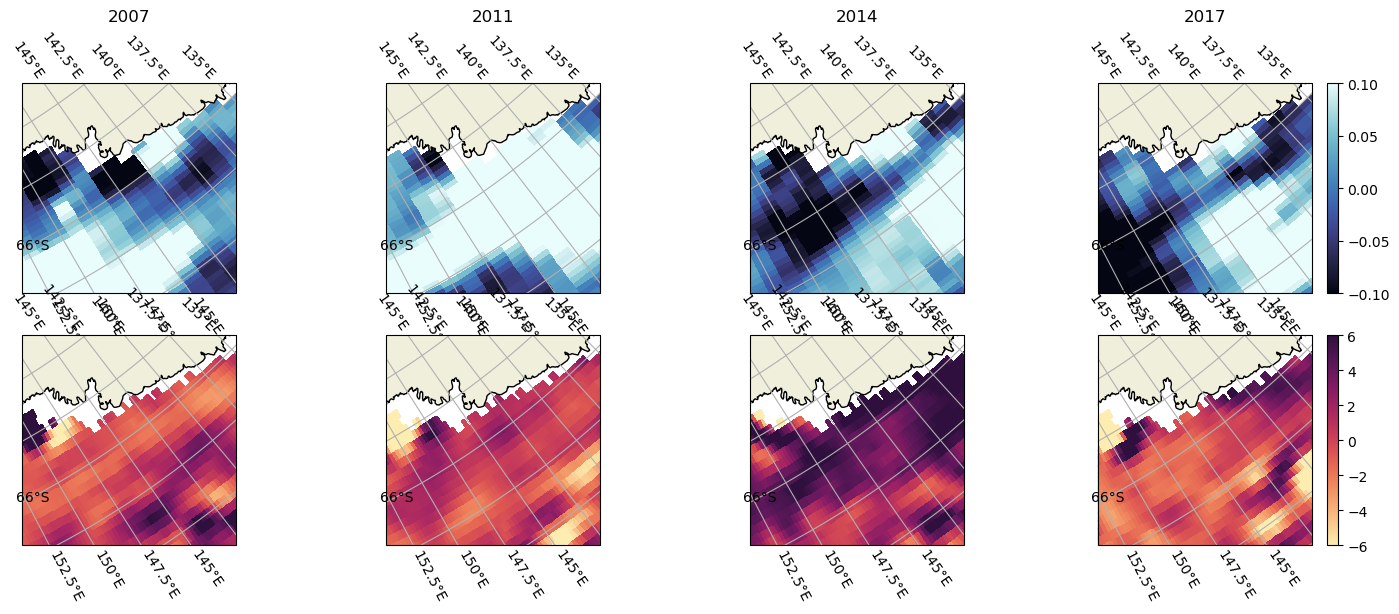

In [23]:
sic_seasons = get_seasons(sice)
sla_seasons = get_seasons(sla)

fig1,ax1 = plt.subplots(2,n,figsize=(18,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})

for i,yr in enumerate(dse_yr.year):
    map_data=sanom(sic_seasons[ss]).where(sic_seasons[ss].time.dt.year == yr,drop=True)
    map_data2=sanom(sla_seasons[ss]).where(sla_seasons[ss].time.dt.year == yr,drop=True)

    im=pfns.sp(ax1[0][i],map_data.mean('time'),extent=extent,cmap=cmocean.cm.ice,land_zorder=1,vmin=-0.1,vmax=0.1)
    im2=pfns.sp(ax1[1][i],map_data2.mean('time'),extent=extent,cmap=cmocean.cm.matter,land_zorder=1,vmin=-6,vmax=6)
    ax1[0][i].set_title(str(yr.item()))


plt.colorbar(im)
plt.colorbar(im2)



In [24]:
o200 = dse.sel(pres=slice(0,200))
temp = o200.temp.to_numpy().flatten()
psal = o200.psal.to_numpy().flatten()
year = np.repeat(o200.year,len(o200.pres))


(-2.1, -0.5)

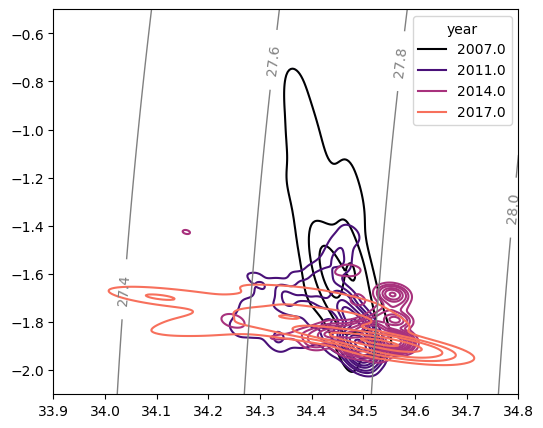

In [69]:
tlim=[-2.1,-0.5]
slim=[33.9,34.8]
colors = plt.cm.magma(np.linspace(0, 0.7, n))
temprange,psalrange,sig0range_ = sig0range(tlim,slim)
fig,ax = plt.subplots(figsize=(6,5))
sns.kdeplot(ax=ax,x=psal,y=temp,hue=year, palette=colors)
cs=ax.contour(psalrange,temprange,sig0range_,levels=4,colors='grey',linewidths=1)
plt.clabel(cs, fontsize=10, inline=1, fmt='%0.1f')
ax.set_xlim(slim)
ax.set_ylim(tlim)

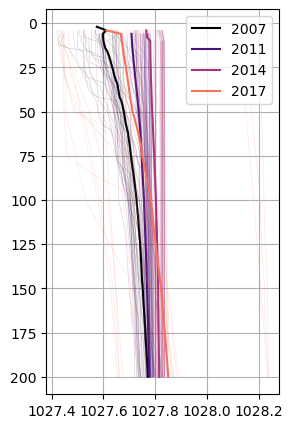

In [70]:
fig,ax = plt.subplots(figsize=(3,5))
y200 = dse_yr.sel(pres=slice(0,200))
for i,y in enumerate(dse_yr.year):
    profs = o200.rho.where(o200.year==y,drop=True)
    for t in profs.time:
        ax.plot(profs.sel(time=t),profs.pres,c=colors[i],alpha=0.2,linewidth=0.4)
    ax.plot(y200.sel(year=y).rho,profs.pres,c=colors[i],label=str(y.item()))

ax.invert_yaxis()
ax.legend()
ax.grid()


In [ ]:
data.mean('time'),extent=extent,cmap=cmocean.cm.ice,land_zorder=3)
plt.colorbar(im)

for ax,yr in zip(ax2,dse_yr.year):
    
    for p in data.time:
        data_=data.sel(time=p)
        im=ax.scatter(data_.psal,data_.temp,c=data_.pres,vmin=0,vmax=200)
    ax.set_xlim([34,34.7])
    ax.set_ylim([-2,0])
plt.colorbar(im)

for ax,yr in zip(ax3,dse_yr.year):
    data=dse.where(dse.year == yr,drop=True)
    for p in data.time:
        data_=data.sel(time=p)
        ax.plot(data_.rho,data.pres,c='navajowhite')
    ax.plot(dse_yr.sel(year=yr).rho,dse_yr.pres,c='darkorange')
    ax.set_title(str(yr.item()) + ' ({} profiles)'.format(dse_yr_cnt.sel(year=yr).dsource.item()))
    ax.grid()
    ax.set_xlim([1027.4,1028])
    ax.set_ylim([0,500])
    ax.invert_yaxis()


    

In [30]:
ds_all.where(ds_all.dsource == 'Argo',drop=True)

<xarray.Dataset> Size: 5MB
Dimensions:       (time: 356, pres: 501)
Coordinates:
  * time          (time) datetime64[ns] 3kB 2006-04-23T04:26:42 ... 2021-12-1...
  * pres          (pres) int64 4kB 0 2 4 6 8 10 12 ... 990 992 994 996 998 1000
    lon           (time) float64 3kB 142.5 143.5 142.9 ... 140.5 140.6 140.6
    lat           (time) float64 3kB -64.01 -64.21 -64.25 ... -64.06 -64.06
    n_prof        (time) float64 3kB 1.199e+05 1.206e+05 ... 2.989e+05 2.989e+05
Data variables:
    temp          (time, pres) float64 1MB nan nan nan ... 1.499 1.496 1.494
    psal          (time, pres) float64 1MB nan nan nan ... 34.74 34.74 34.74
    dsource       (time) object 3kB 'Argo' 'Argo' 'Argo' ... 'Argo' 'Argo'
    mld           (time) float64 3kB 83.76 63.96 78.81 ... 43.47 35.55 47.43
    asal          (time, pres) float32 713kB nan nan nan ... 34.91 34.91 34.91
    ctemp         (time, pres) float32 713kB nan nan nan ... 1.498 1.496 1.494
    rho           (time, pres) float32 713kB nan nan nan ... 1.028e+03 1.028e+03
    mlp           (time) float64 3kB 82.0 60.0 78.0 74.0 ... 36.0 40.0 36.0 46.0
    profile_code  (time) object 3kB nan nan nan nan nan ... nan nan nan nan nan
    elevation     (time) float64 3kB -3.79e+03 -3.639e+03 ... -3.637e+03
    month         (time) float64 3kB 4.0 5.0 5.0 5.0 ... 12.0 12.0 12.0 12.0
    year          (time) float64 3kB 2.006e+03 2.006e+03 ... 2.021e+03 2.021e+03
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [26]:
dse.where(dse.year==2017,drop=True).isel(pres=3)

<xarray.Dataset> Size: 3kB
Dimensions:       (time: 29)
Coordinates:
  * time          (time) datetime64[ns] 232B 2017-11-09T21:30:00.000003 ... 2...
    pres          int64 8B 6
    lon           (time) float64 232B 140.1 141.7 142.2 ... 142.1 142.1 142.1
    lat           (time) float64 232B -66.62 -66.49 -66.51 ... -65.83 -65.83
    n_prof        (time) float64 232B 7.932e+05 7.932e+05 ... 7.932e+05
Data variables:
    temp          (time) float64 232B -1.862 -1.817 -1.811 ... -1.589 -1.614
    psal          (time) float64 232B 34.2 34.27 34.33 ... 34.09 34.07 34.07
    dsource       (time) object 232B 'MEOP' 'MEOP' 'MEOP' ... 'MEOP' 'MEOP'
    mld           (time) float64 232B 23.76 49.5 29.7 43.56 ... 49.5 49.5 49.5
    asal          (time) float32 116B 34.36 34.44 34.5 ... 34.25 34.23 34.23
    ctemp         (time) float32 116B -1.858 -1.813 -1.807 ... -1.586 -1.61
    rho           (time) float32 116B 1.028e+03 1.028e+03 ... 1.027e+03
    mlp           (time) float64 232B 22.0 42.0 22.0 42.0 ... 38.0 30.0 32.0
    profile_code  (time) object 232B nan nan nan nan nan ... nan nan nan nan nan
    elevation     (time) float64 232B -602.0 -399.0 -362.0 ... -427.3 -463.5
    month         (time) float64 232B 11.0 11.0 11.0 11.0 ... 12.0 12.0 12.0
    year          (time) float64 232B 2.017e+03 2.017e+03 ... 2.017e+03
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [32]:
dsw.where(dsw.year==2017,drop=True).isel(pres=3).rho

<xarray.DataArray 'rho' (time: 9)> Size: 36B
array([1027.5352, 1027.6051, 1027.5251, 1027.4342, 1027.4409, 1027.4647,
       1028.164 , 1028.1091, 1028.1913], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 72B 2017-11-09T21:30:00.000003 ... 2017-12...
    pres     int64 8B 6
    lon      (time) float64 72B 140.1 140.1 140.2 140.2 ... 140.2 140.2 141.0
    lat      (time) float64 72B -66.62 -66.63 -66.6 ... -66.55 -66.62 -66.77
    n_prof   (time) float64 72B 7.932e+05 7.932e+05 ... 5.99e+05 5.99e+05
Attributes:
    long_name:      In-situ Density
    standard_name:  rho
    units:          kg/m^-3

In [42]:
ds_shelf.rho.where(ds_shelf.rho > 1028,drop=True)

<xarray.DataArray 'rho' (time: 9, pres: 322)> Size: 12kB
array([[      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       ...,
       [1028.164 , 1028.1647, 1028.1654, ...,       nan,       nan,
              nan],
       [1028.1091, 1028.1112, 1028.1133, ...,       nan,       nan,
              nan],
       [1028.1913, 1028.1936, 1028.1959, ...,       nan,       nan,
              nan]], dtype=float32)
Coordinates:
    lon      (time) float64 72B 141.2 141.1 141.1 141.1 ... 140.2 140.2 141.0
    lat      (time) float64 72B -66.54 -66.78 -66.59 ... -66.55 -66.62 -66.77
  * time     (time) datetime64[ns] 72B 2007-06-28T02:39:58.999996 ... 2017-12...
    n_prof   (time) int64 72B 793301 673587 673562 ... 598956 598957 598958
  * pres     (pres) int64 3kB 6 8 10 12 14 16 18 ... 754 756 758 760 762 764 766
Attributes:
    long_name:      In-situ Density
    standard_name:  rho
    units:          kg/m^-3

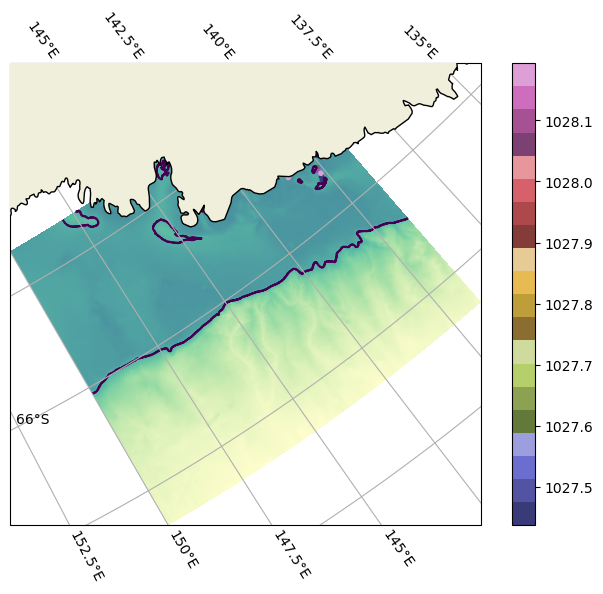

In [38]:
data = dsw.where(dsw.year==2017,drop=True)
fig,ax=plt.subplots(figsize=(8,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax,elevation,extent=extent,cmap=cmocean.cm.deep,land_zorder=3)

im=ax.scatter(data.lon,data.lat,c=data.rho.isel(pres=4),transform=ccrs.PlateCarree(),marker='.',cmap='tab20b')
ax.contour(elevation.longitude,elevation.latitude, elevation,levels=[-1000],transform=ccrs.PlateCarree())
plt.colorbar(im)

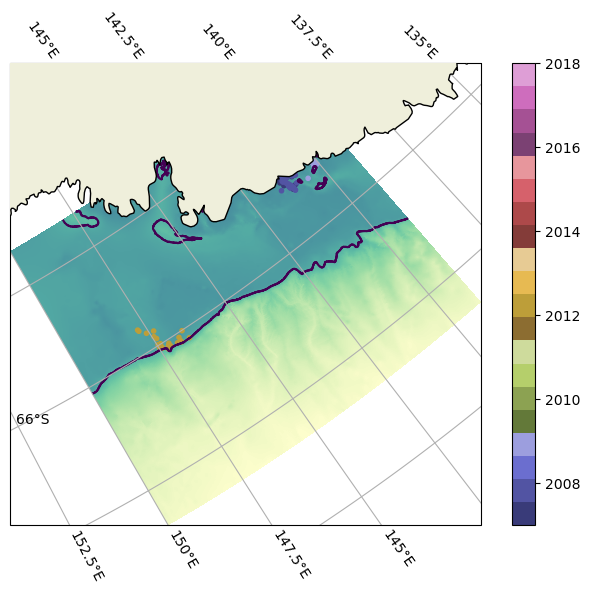

In [55]:
ssn=seasons['winter']
ssn['year'] = ssn.time.dt.year

fig,ax=plt.subplots(figsize=(8,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax,elevation,extent=extent,cmap=cmocean.cm.deep,land_zorder=3)

im=ax.scatter(ssn.lon,ssn.lat,c=ssn.year,transform=ccrs.PlateCarree(),marker='.',cmap='tab20b')
ax.contour(elevation.longitude,elevation.latitude, elevation,levels=[-1000],transform=ccrs.PlateCarree())
plt.colorbar(im)

In [87]:
data_.to_dataframe()

,temp,psal,dsource,mld,asal,ctemp,rho,mlp,elevation,month,year,lon,lat,time,n_prof
pres,,,,,,,,,,,,,,,
0,NaN,NaN,SOCCOM,118.771225,NaN,NaN,NaN,120.0,-72.696,9.0,2018,140.367,-67.22,2018-09-28 15:25:00.000001024,799118
2,NaN,NaN,SOCCOM,118.771225,NaN,NaN,NaN,120.0,-72.696,9.0,2018,140.367,-67.22,2018-09-28 15:25:00.000001024,799118
4,NaN,NaN,SOCCOM,118.771225,NaN,NaN,NaN,120.0,-72.696,9.0,2018,140.367,-67.22,2018-09-28 15:25:00.000001024,799118
6,NaN,NaN,SOCCOM,118.771225,NaN,NaN,NaN,120.0,-72.696,9.0,2018,140.367,-67.22,2018-09-28 15:25:00.000001024,799118
8,NaN,NaN,SOCCOM,118.771225,NaN,NaN,NaN,120.0,-72.696,9.0,2018,140.367,-67.22,2018-09-28 15:25:00.000001024,799118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992,0.335580,34.682620,SOCCOM,118.771225,34.849487,0.336616,1027.839722,120.0,-72.696,9.0,2018,140.367,-67.22,2018-09-28 15:25:00.000001024,799118
994,0.335046,34.682561,SOCCOM,118.771225,34.849426,0.336083,1027.839722,120.0,-72.696,9.0,2018,140.367,-67.22,2018-09-28 15:25:00.000001024,799118
996,0.334511,34.682501,SOCCOM,118.771225,34.849369,0.335549,1027.839722,120.0,-72.696,9.0,2018,140.367,-67.22,2018-09-28 15:25:00.000001024,799118


ValueError: cannot handle a non-unique multi-index!

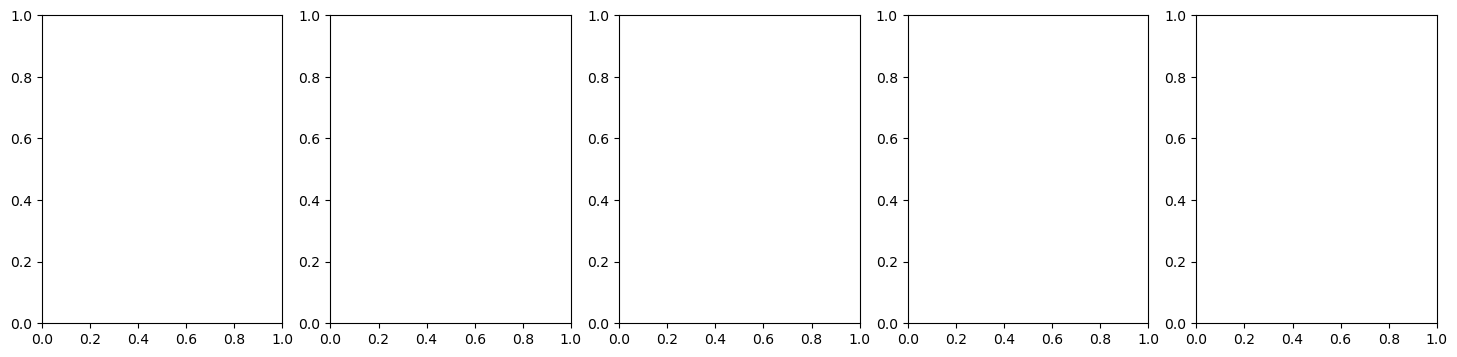

In [90]:
ds_yr = ssn.groupby('time.year').mean()
ds_yr_cnt = ssn.groupby('time.year').count()

fig,ax = plt.subplots(1,len(ds_yr.year),figsize=(18,4))
for i,yr in enumerate(ds_yr.year):
    data_=ssn.where(ssn.year == yr,drop=True)
    sns.kdeplot(ax=ax[i],data=data_.to_dataframe(),x='psal',y='temp')

fig,ax = plt.subplots(1,len(ds_yr.year),figsize=(18,6))

for i,yr in enumerate(ds_yr.year):
    data=ssn.where(ssn.year == yr,drop=True)
    for p in data.time:
        data_=data.sel(time=p)
        try:
            ax[i].plot(data_.rho,data.pres,c='navajowhite')
        except:
            for l in data_.lat:
                ax[i].plot(data_.rho.swap_dims({'time':'lat'}).sel(lat=l),data.pres,c='navajowhite')
    ax[i].plot(ds_yr.sel(year=yr).rho,ds_yr.pres,c='darkorange')
    ax[i].set_title(str(yr.item()) + ' ({} profiles)'.format(ds_yr_cnt.sel(year=yr).dsource.item()))
    ax[i].invert_yaxis()
    ax[i].grid()
    ax[i].set_xlim([1027.4,1028.4])
    ax[i].set_ylim([0,600])

preparing lag=0 months
preparing data
plotting..
preparing lag=1 months
preparing data
plotting..
preparing lag=2 months
preparing data
plotting..
preparing lag=3 months
preparing data
plotting..
preparing lag=4 months
preparing data
plotting..
preparing lag=5 months
preparing data
plotting..
preparing lag=6 months
preparing data
plotting..


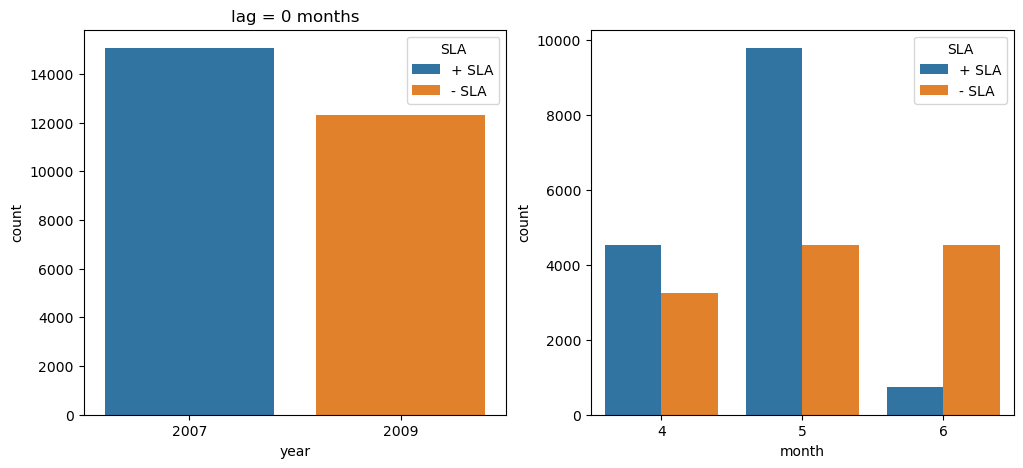

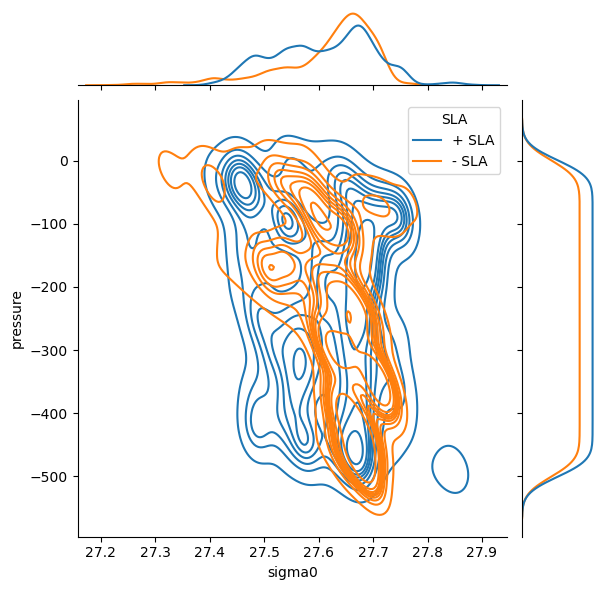

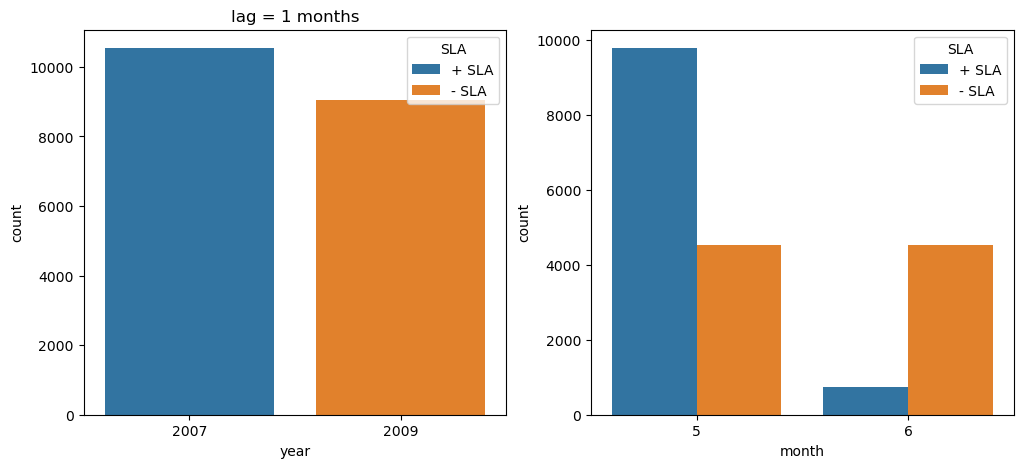

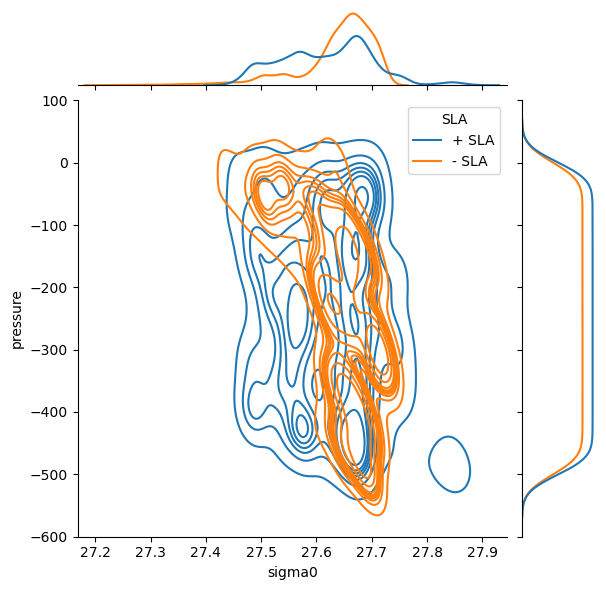

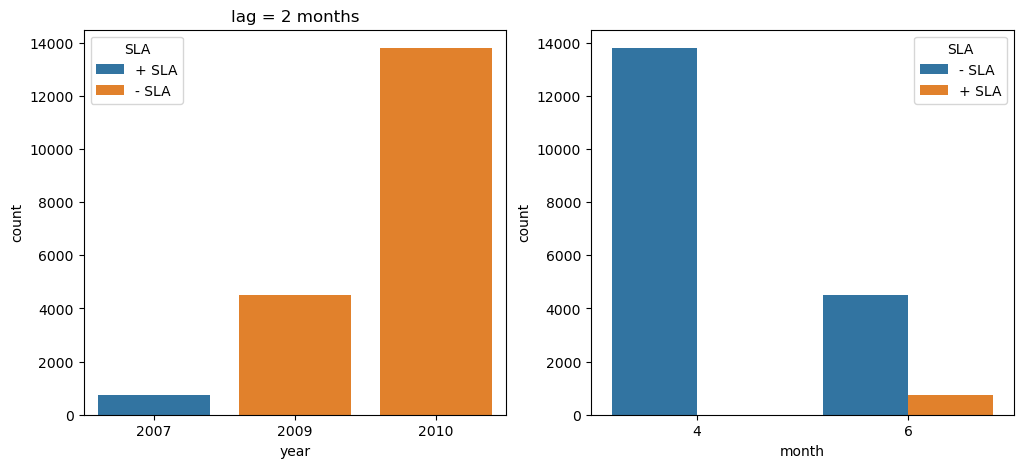

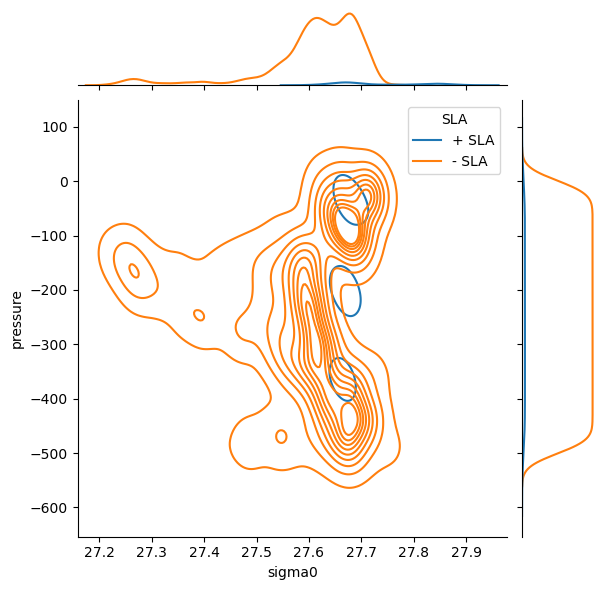

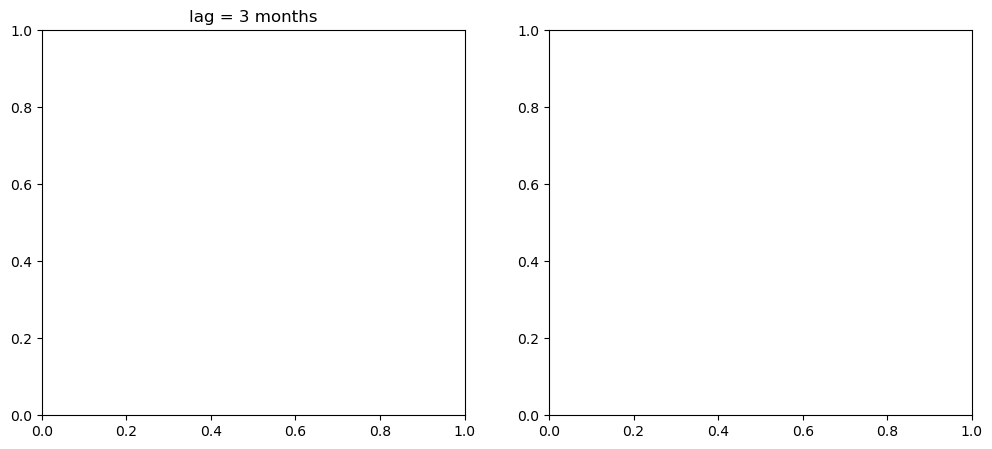

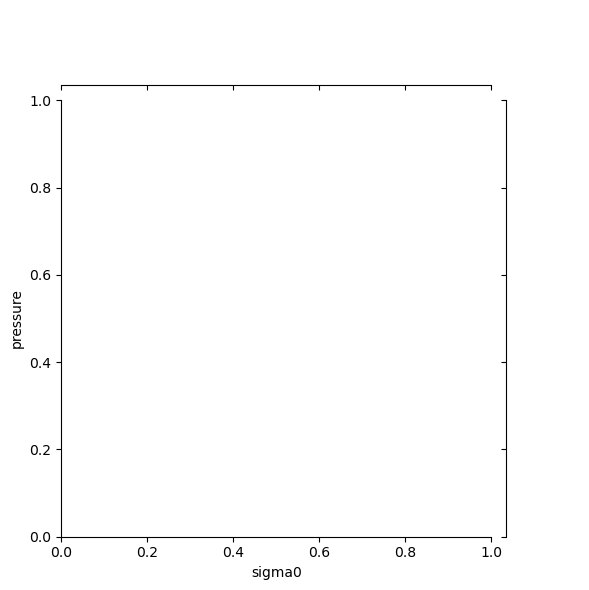

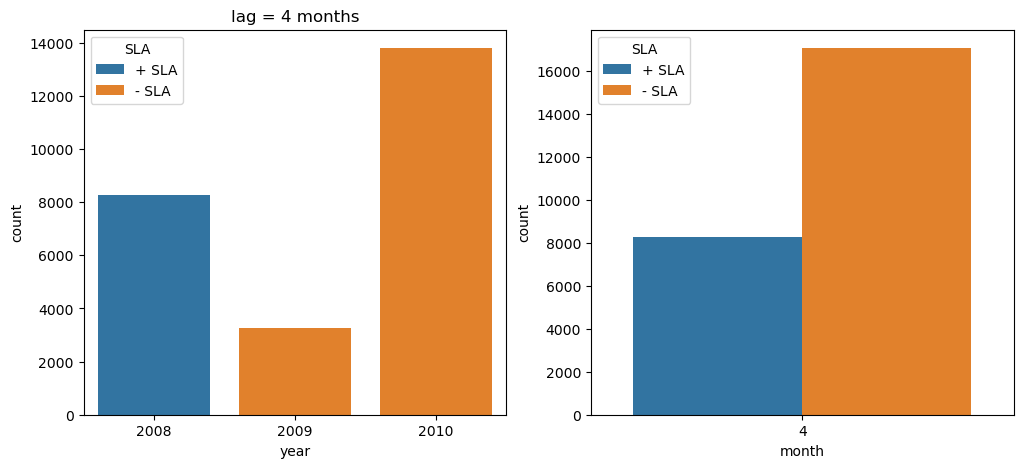

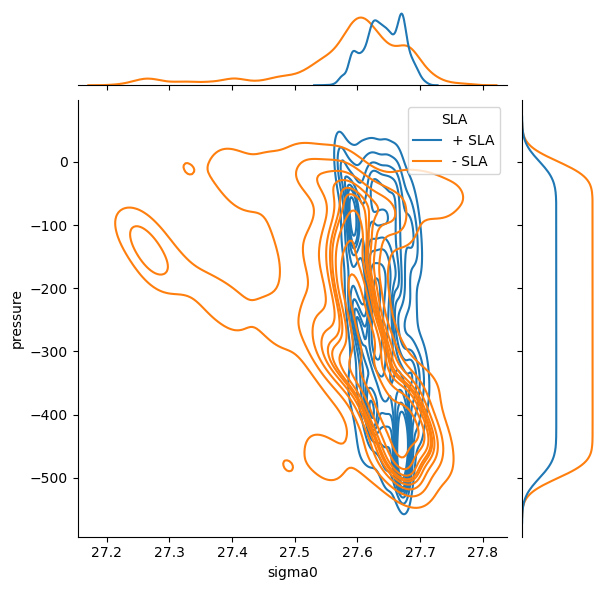

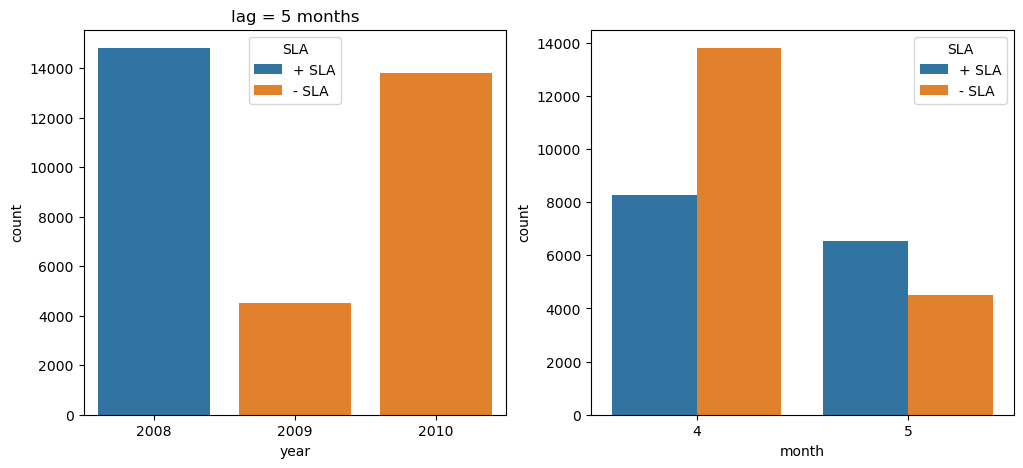

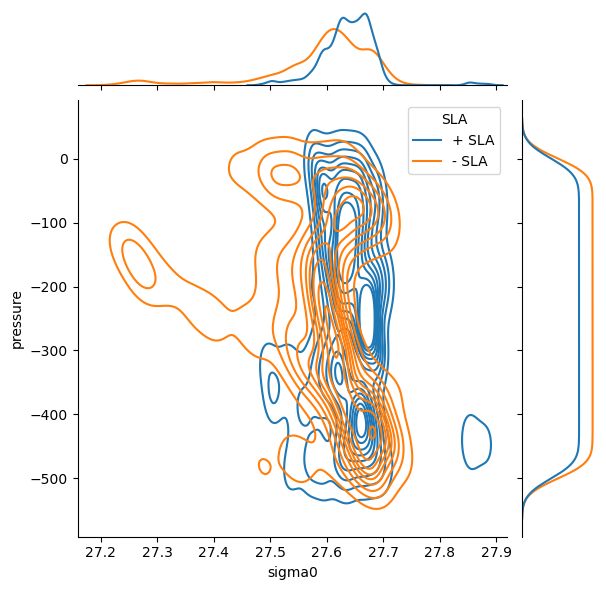

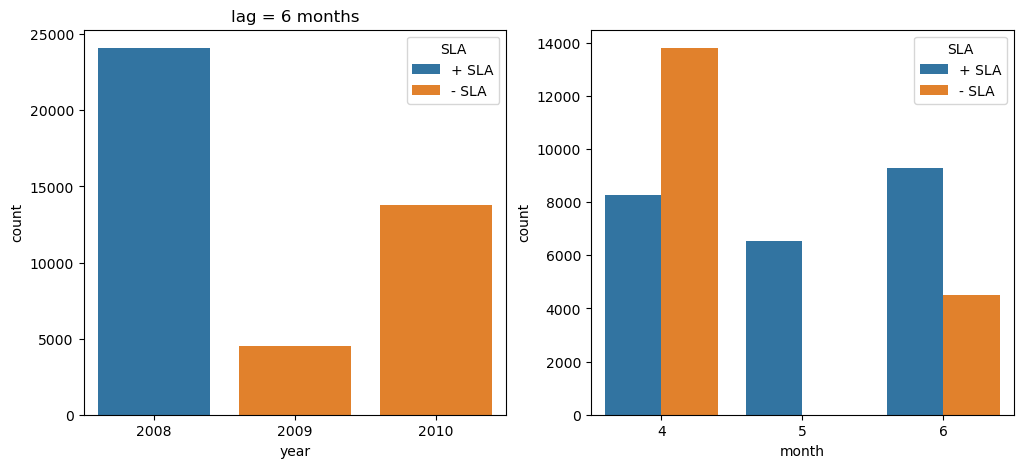

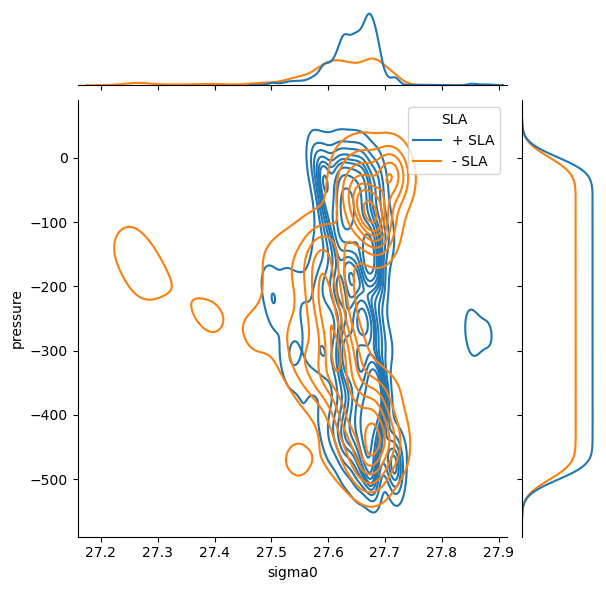

In [ ]:
background_data = sanom(mertz.crop_da(sla)).mean(['latitude','longitude'])
background_data = utls.detrend_dim(background_data,'time')
idx_data = background_data.rolling(time=12,center=True).mean('time')

for l in np.arange(7):
    print('preparing lag={} months'.format(l))
    cmp = Composite(idx_data,'SLA')
    cmp.add_spira(seasons['autumn'],tlims=tlims,slims=slims,lag=l)
    cmp.build_sns_data()

    fig, ax = plt.subplots(1,2,figsize=(12,5))
    sns.countplot(cmp.sns_data, x='year', hue='SLA',ax=ax[0])
    sns.countplot(cmp.sns_data, x='month', hue='SLA',ax=ax[1])
    ax[0].set_title('lag = {} months'.format(l))

    print('plotting..')
    g = sns.JointGrid(data=cmp.sns_data, x='sigma0', y ='pressure', hue='SLA')
    g.plot(sns.kdeplot, sns.kdeplot)

In [32]:
cmp = Composite(idx_data,'SLA')
cmp.add_spira(seasons['autumn'],tlims=tlims,slims=slims,lag=4)
cmp.build_sns_data()

preparing data


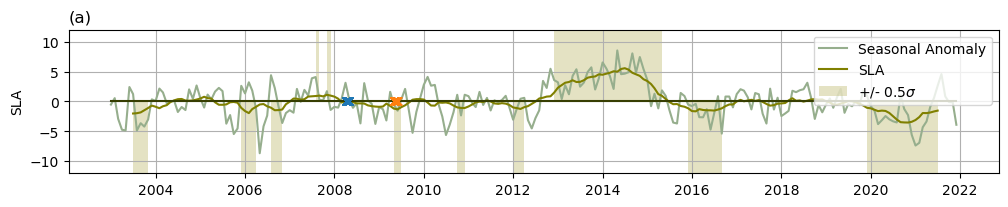

In [33]:
fig = plt.figure(figsize=(12,22))
gs = fig.add_gridspec(10,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])

cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly')

ValueError: x and y must have same first dimension, but have shapes (2, 251) and (251,)

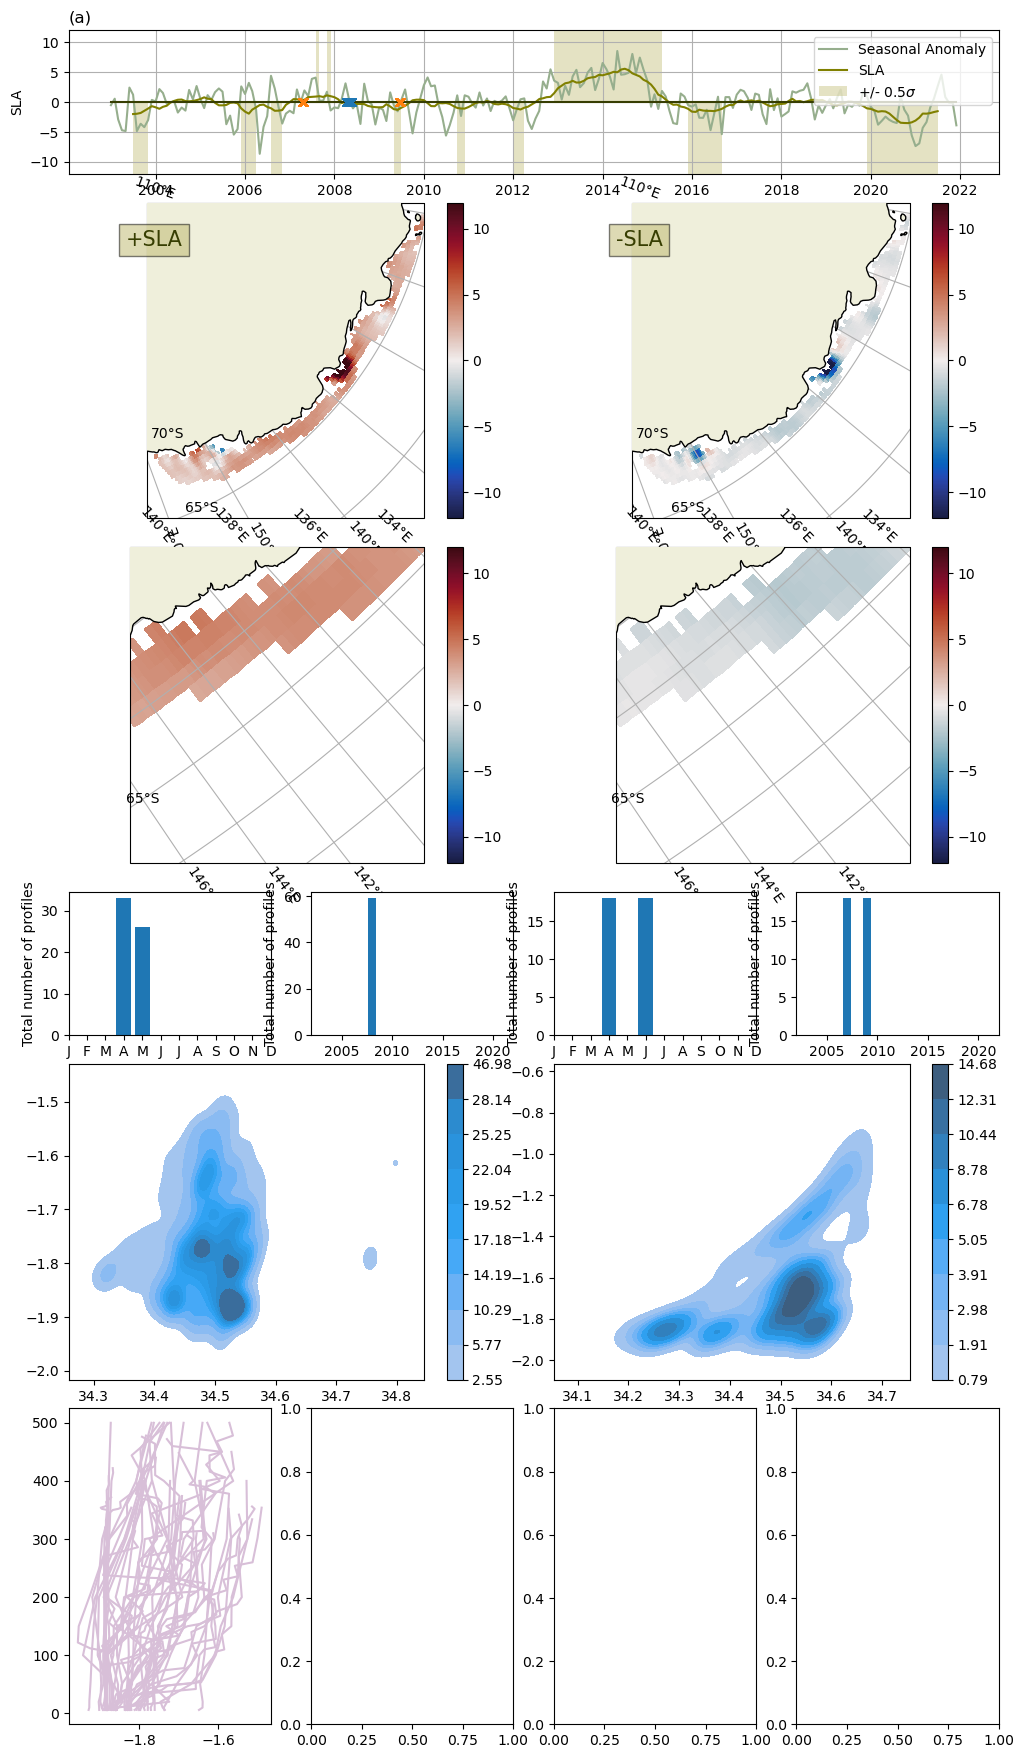

In [29]:
fig = plt.figure(figsize=(12,22))
gs = fig.add_gridspec(10,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])

cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly')
# FIG2: SLA MAP
ax2 = fig.add_subplot(gs[1:3, 0:2],projection=ccrs.SouthPolarStereo())
ax3 = fig.add_subplot(gs[1:3, 2:4],projection=ccrs.SouthPolarStereo())
cmp.posneg_map([ax2,ax3],sanom(shelf.crop_da(sla)),'SLA',12,extent,label_loc=[130,-80])

# FIG3: SLA closeup
ax4 = fig.add_subplot(gs[3:5, 0:2],projection=ccrs.SouthPolarStereo())
ax5 = fig.add_subplot(gs[3:5, 2:4],projection=ccrs.SouthPolarStereo())
cmp.posneg_map([ax4,ax5],sanom(shelf.crop_da(sla)),'SLA',12,extent_mertz,add_profiles=True)

n = 5
cmp.ts_freq_plot([ 
    fig.add_subplot(gs[n,0]),
    fig.add_subplot(gs[n,1]),
    fig.add_subplot(gs[n,2]),
    fig.add_subplot(gs[n,3]),
])

# FIG4: TS DESNITY
n = 6
# cmp.ts_density([
    # fig.add_subplot(gs[n:n+2,0:2]),
    # fig.add_subplot(gs[n:n+2,2:4])
    # ])

ax6 = fig.add_subplot(gs[n:n+2,0:2])
ax7 = fig.add_subplot(gs[n:n+2,2:4])

sns.kdeplot(ax=ax6,x=cmp.s_pos.values.flatten(), y=cmp.t_pos.values.flatten(), fill=True, cbar=True)
sns.kdeplot(ax=ax7, x=cmp.s_neg.values.flatten(), y=cmp.t_neg.values.flatten(),fill=True, cbar=True)

# FIG5: TS PROFILES
n = 8
ax8 = fig.add_subplot(gs[8:10,0])
ax9 = fig.add_subplot(gs[8:10,1])
ax10 = fig.add_subplot(gs[8:10,2])
ax11 = fig.add_subplot(gs[8:10,3])
cmp.ts_profiles([ax8,ax9,ax10,ax11])

plt.tight_layout()



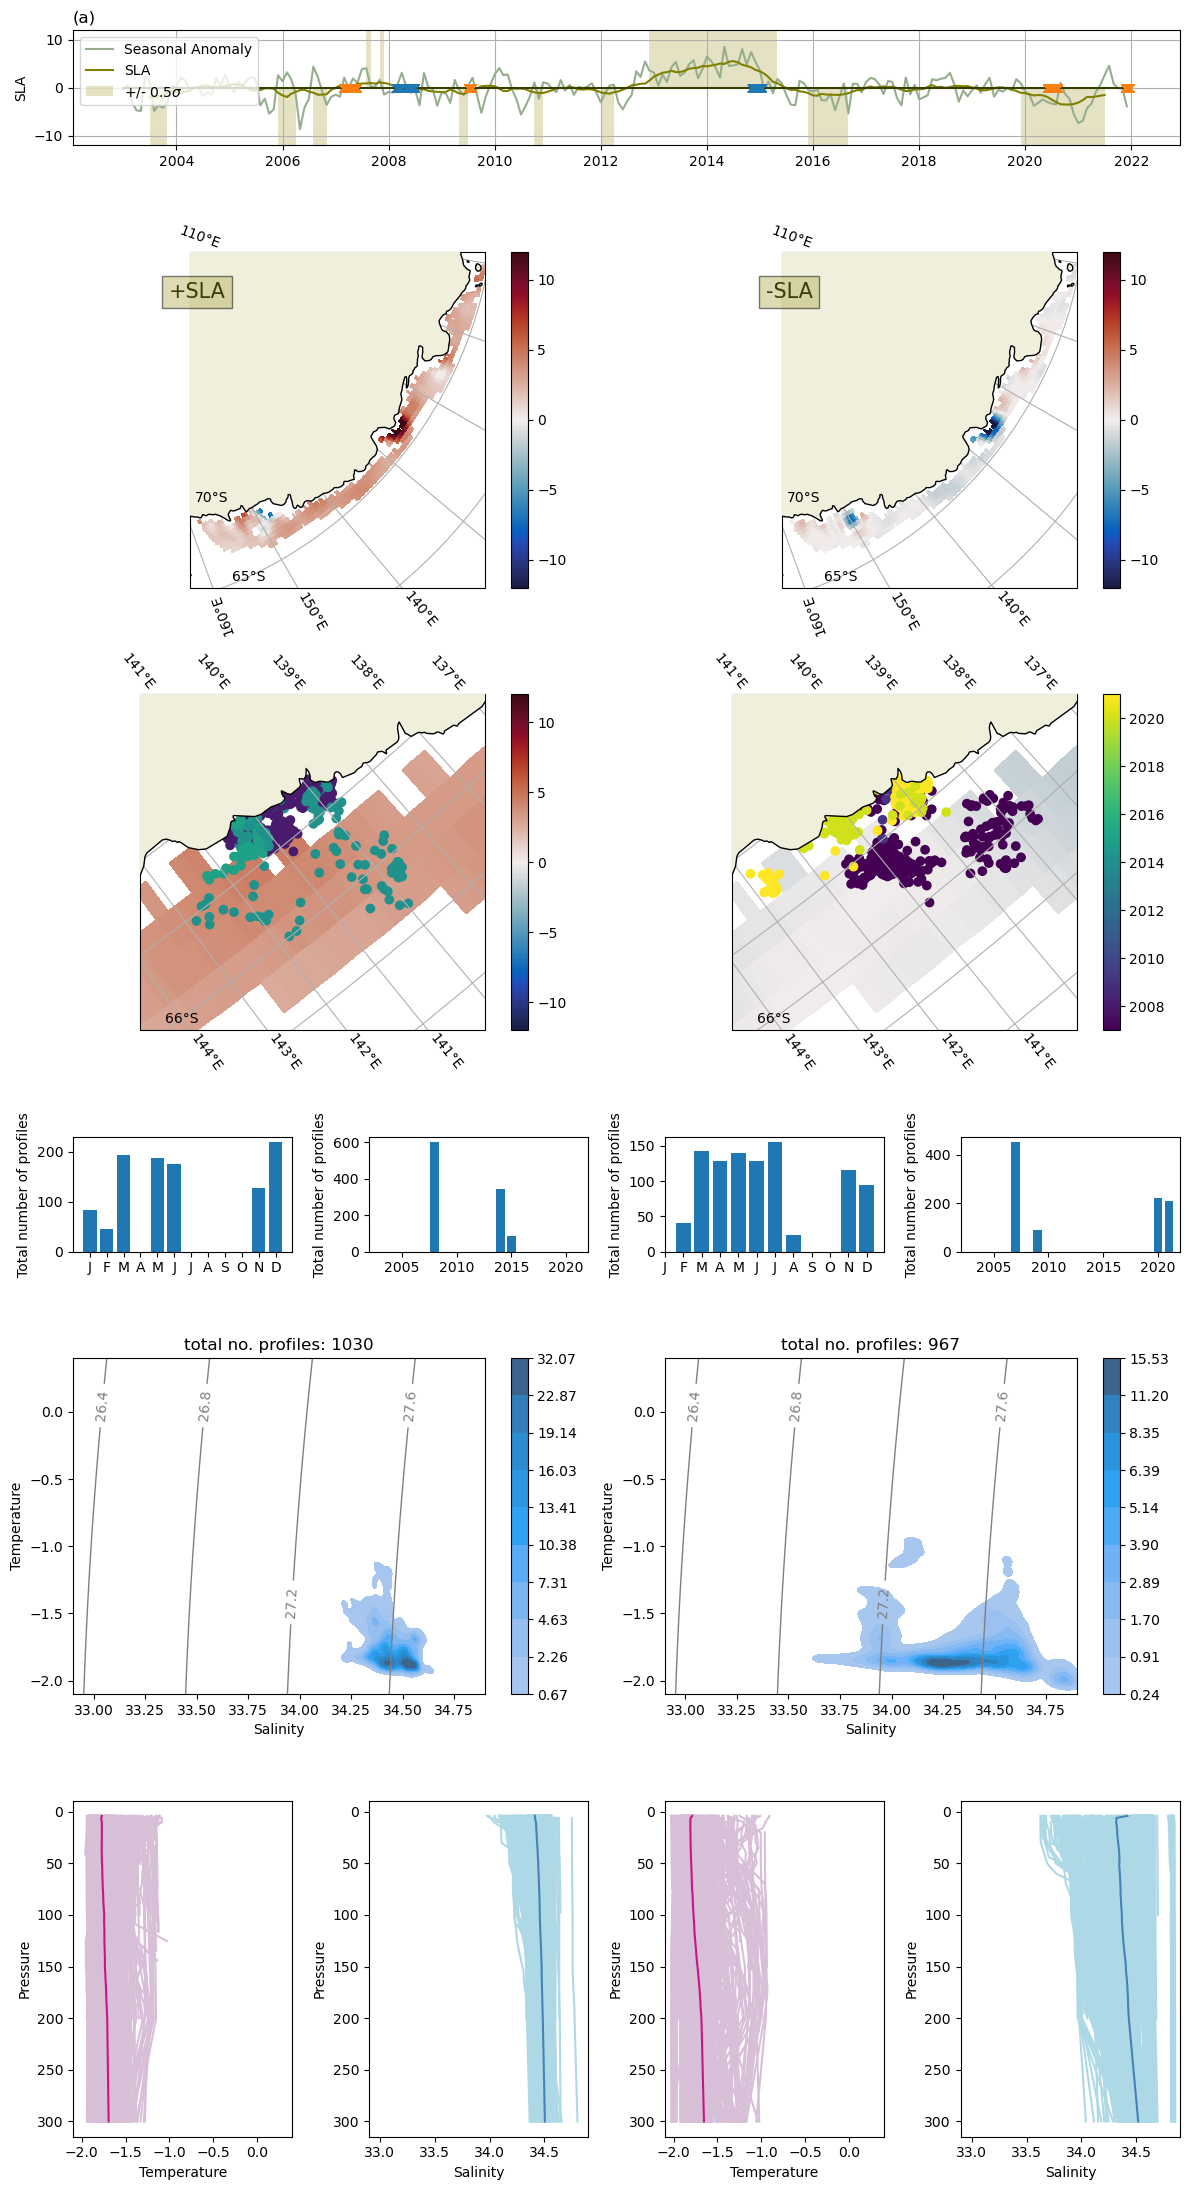

In [ ]:
fig = plt.figure(figsize=(12,22))
gs = fig.add_gridspec(10,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])

cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly')
# FIG2: SLA MAP
ax2 = fig.add_subplot(gs[1:3, 0:2],projection=ccrs.SouthPolarStereo())
ax3 = fig.add_subplot(gs[1:3, 2:4],projection=ccrs.SouthPolarStereo())
cmp.posneg_map([ax2,ax3],sanom(shelf.crop_da(sla)),'SLA',12,extent,label_loc=[130,-80])

# FIG3: SLA closeup
ax4 = fig.add_subplot(gs[3:5, 0:2],projection=ccrs.SouthPolarStereo())
ax5 = fig.add_subplot(gs[3:5, 2:4],projection=ccrs.SouthPolarStereo())
cmp.posneg_map([ax4,ax5],sanom(shelf.crop_da(sla)),'SLA',12,extent_mertz,add_profiles=True)

n = 5
cmp.ts_freq_plot([ 
    fig.add_subplot(gs[n,0]),
    fig.add_subplot(gs[n,1]),
    fig.add_subplot(gs[n,2]),
    fig.add_subplot(gs[n,3]),
])

# FIG4: TS DESNITY
n = 6
cmp.ts_density([
    fig.add_subplot(gs[n:n+2,0:2]),
    fig.add_subplot(gs[n:n+2,2:4])
    ])

# FIG5: TS PROFILES
n = 8
ax8 = fig.add_subplot(gs[8:10,0])
ax9 = fig.add_subplot(gs[8:10,1])
ax10 = fig.add_subplot(gs[8:10,2])
ax11 = fig.add_subplot(gs[8:10,3])
cmp.ts_profiles([ax8,ax9,ax10,ax11])

plt.tight_layout()



In [18]:
tm_pos,p_pos = np.meshgrid(cmp.t_pos.time,cmp.t_pos.pressure)
tm_neg,p_neg = np.meshgrid(cmp.t_neg.time,cmp.t_neg.pressure)
p_pos = p_pos.flatten()
p_neg=p_neg.flatten()
tm_pos = tm_pos.flatten()
tm_neg = tm_neg.flatten()
rho_pos = gsw.density.sigma0(cmp.s_pos.values,cmp.t_pos.values).flatten()
rho_neg = gsw.density.sigma0(cmp.s_neg.values,cmp.t_neg.values).flatten()

In [22]:
sns_data = pd.DataFrame(data={'time':np.concatenate([tm_pos,tm_neg]),
                              'temperature':np.concatenate([cmp.t_pos.values.flatten(),cmp.t_neg.values.flatten()]),
                              'salinity':np.concatenate([cmp.s_pos.values.flatten(),cmp.s_neg.values.flatten()]),
                              'pressure':-np.concatenate([p_pos,p_neg]),
                              'potential density': np.concatenate([rho_pos,rho_neg]),
                              'SLA': ['+ SLA' for _ in tm_pos] + ['- SLA' for _ in tm_neg],
                              'month': get_month(np.concatenate([tm_pos,tm_neg])),
                              'year': pd.to_datetime(np.concatenate([tm_pos,tm_neg])).year
                              })

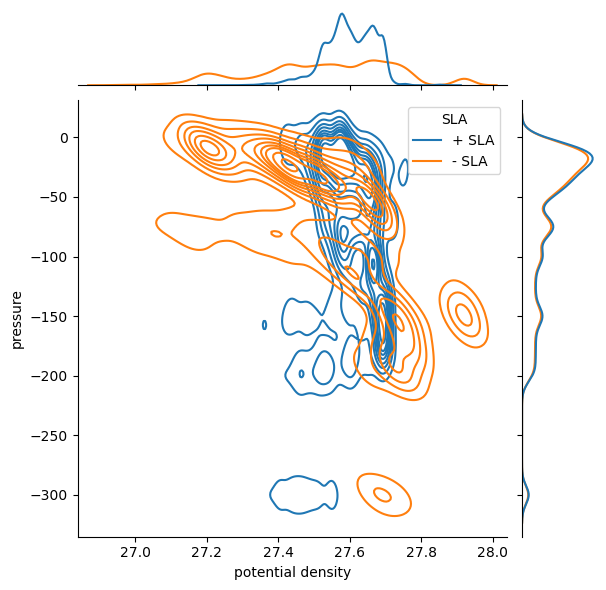

In [23]:
g = sns.JointGrid(data=sns_data, x='potential density', y ='pressure', hue='SLA')
g.plot(sns.kdeplot, sns.kdeplot)

In [24]:
background_data = sanom(sla_shelf).mean(['latitude','longitude'])
background_data = utls.detrend_dim(background_data,'time')
idx_data = background_data.rolling(time=12,center=True).mean('time')

cmp = Composite(idx_data,'SLA')
cmp.add_meop(meop_mertz,tlims=tlims,slims=slims,lag=2)

reindexing temps..
reindexing psals...
merging...
reindexing temps..
reindexing psals...
merging...


In [26]:
tm_pos,p_pos = np.meshgrid(cmp.t_pos.time,cmp.t_pos.pressure)
tm_neg,p_neg = np.meshgrid(cmp.t_neg.time,cmp.t_neg.pressure)
p_pos = p_pos.flatten()
p_neg=p_neg.flatten()
tm_pos = tm_pos.flatten()
tm_neg = tm_neg.flatten()
rho_pos = gsw.density.sigma0(cmp.s_pos.values,cmp.t_pos.values).flatten()
rho_neg = gsw.density.sigma0(cmp.s_neg.values,cmp.t_neg.values).flatten()
ssn_pos = [get_season(t) for t in tm_pos]
ssn_neg = [get_season(t) for t in tm_neg]

In [27]:
sns_data = pd.DataFrame(data={'time':np.concatenate([tm_pos,tm_neg]),
                              'temperature':np.concatenate([cmp.t_pos.values.flatten(),cmp.t_neg.values.flatten()]),
                              'salinity':np.concatenate([cmp.s_pos.values.flatten(),cmp.s_neg.values.flatten()]),
                              'pressure':-np.concatenate([p_pos,p_neg]),
                              'potential density': np.concatenate([rho_pos,rho_neg]),
                              'SLA': ['+ SLA' for _ in tm_pos] + ['- SLA' for _ in tm_neg],
                              'month': get_month(np.concatenate([tm_pos,tm_neg])),
                              'year': pd.to_datetime(np.concatenate([tm_pos,tm_neg])).year
                              })

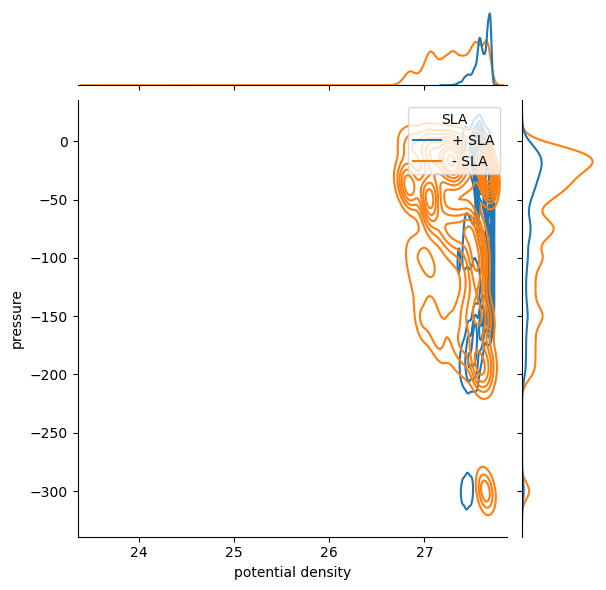

In [28]:
g = sns.JointGrid(data=sns_data, x='potential density', y ='pressure', hue='SLA')
g.plot(sns.kdeplot, sns.kdeplot)

In [29]:
background_data = sanom(sla_shelf).mean(['latitude','longitude'])
background_data = utls.detrend_dim(background_data,'time')
idx_data = background_data.rolling(time=12,center=True).mean('time')

cmp = Composite(idx_data,'SLA')
cmp.add_meop(meop_mertz,tlims=tlims,slims=slims,lag=3)
tm_pos,p_pos = np.meshgrid(cmp.t_pos.time,cmp.t_pos.pressure)
tm_neg,p_neg = np.meshgrid(cmp.t_neg.time,cmp.t_neg.pressure)
p_pos = p_pos.flatten()
p_neg=p_neg.flatten()
tm_pos = tm_pos.flatten()
tm_neg = tm_neg.flatten()
rho_pos = gsw.density.sigma0(cmp.s_pos.values,cmp.t_pos.values).flatten()
rho_neg = gsw.density.sigma0(cmp.s_neg.values,cmp.t_neg.values).flatten()
ssn_pos = [get_season(t) for t in tm_pos]
ssn_neg = [get_season(t) for t in tm_neg]
sns_data = pd.DataFrame(data={'time':np.concatenate([tm_pos,tm_neg]),
                              'temperature':np.concatenate([cmp.t_pos.values.flatten(),cmp.t_neg.values.flatten()]),
                              'salinity':np.concatenate([cmp.s_pos.values.flatten(),cmp.s_neg.values.flatten()]),
                              'pressure':-np.concatenate([p_pos,p_neg]),
                              'potential density': np.concatenate([rho_pos,rho_neg]),
                              'SLA': ['+ SLA' for _ in tm_pos] + ['- SLA' for _ in tm_neg],
                              'month': get_month(np.concatenate([tm_pos,tm_neg])),
                              'year': pd.to_datetime(np.concatenate([tm_pos,tm_neg])).year
                              })

reindexing temps..
reindexing psals...
merging...
reindexing temps..
reindexing psals...
merging...


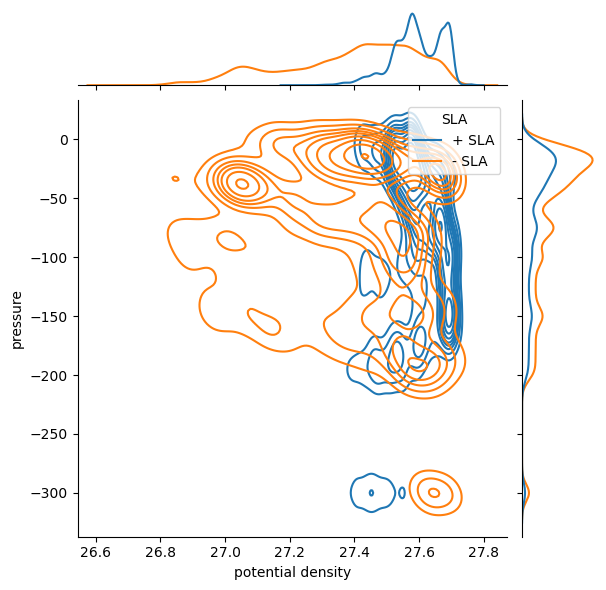

In [30]:
g = sns.JointGrid(data=sns_data, x='potential density', y ='pressure', hue='SLA')
g.plot(sns.kdeplot, sns.kdeplot)